Base consolidada: 510842 predições de clusters esparsos mineradas com sucesso.


,Modelo,MAPE (Sem Zeros) %,sMAPE Bruto (%),sMAPE Pós (%),WAPE Bruto (%),WAPE Pós (%),Falsos Alertas Evitados
0,Baseline,107.58,61.22,61.22,76.62,76.62,19
1,XGBoost,72.33,110.47,50.65,54.90,52.48,39667
2,GRU,78.73,128.35,55.95,60.97,59.25,47200
3,LSTM,85.77,128.05,119.07,114.89,114.27,5679


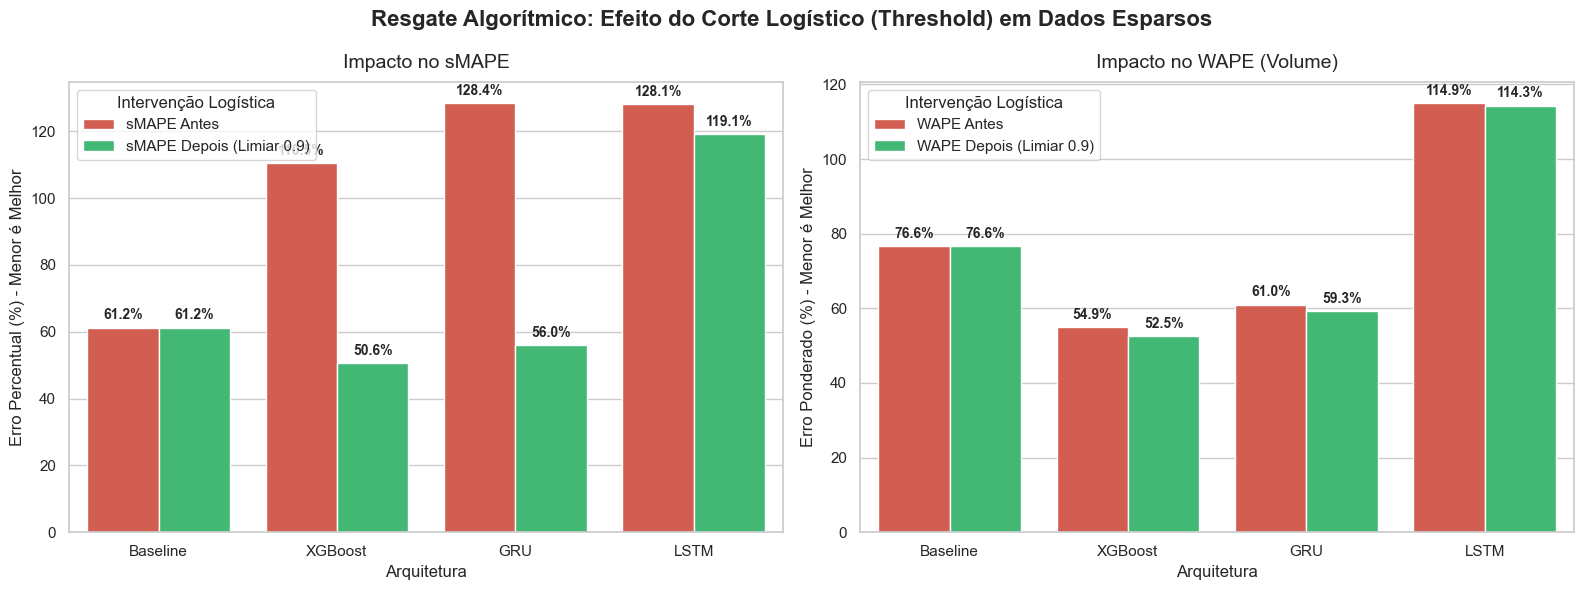

In [2]:
# %% [markdown]
# # Pós-Processamento e Segmentação de Erros (Error Analysis Comparativo)
# 
# ## Objetivo
# Analisar as previsões brutas de todas as arquiteturas avaliadas em cenários de demanda esparsa, aplicando heurísticas de pós-processamento (Thresholding) para comparar a sensibilidade de cada modelo ao ruído matemático diário.
# 
# ## Contextualização
# Modelos preditivos reagem de forma diferente à intermitência do varejo. O *Baseline* copia zeros passados, o *XGBoost* isola zeros através de ramificações lógicas, e arquiteturas de *Deep Learning* (LSTM/GRU) aproximam-se do zero via funções de ativação contínuas, gerando ruídos residuais (ex: prever `0.6` em um dia de venda zero).
# 
# Este notebook consolida as previsões dos modelos para clusters de baixa/intermitente demanda, avaliando as distorções no sMAPE e demonstrando como uma regra de negócio simples (limiar de corte logístico) reduz o risco de superestoque. O MAPE tradicional foi incluído apenas para demonstração de sua fragilidade estatística em dados esparsos.

# %%
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# --- Funções Matemáticas Essenciais ---

def calculate_mape(y_true, y_pred):
    """MAPE Tradicional: Adicionado para demonstrar a falha em dias de venda zero."""
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.abs((y_true - y_pred) / y_true) * 100
    if isinstance(mape, pd.Series): return mape.replace([np.inf, -np.inf], np.nan)
    return np.where(np.isinf(mape), np.nan, mape)

def calculate_smape(y_true, y_pred):
    """sMAPE: Limita o erro a 200%, punindo ruídos fracionados em dias zerados."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        smape = np.abs(y_true - y_pred) / denominator * 100
    if isinstance(smape, pd.Series): return smape.fillna(0)
    return np.nan_to_num(smape, nan=0.0)

def calculate_wape(y_true, y_pred):
    """WAPE: Erro Logístico Ponderado pelo Volume. Imune à divisão por zero."""
    soma_real = np.sum(y_true)
    if soma_real == 0: return 0.0
    return (np.sum(np.abs(y_true - y_pred)) / soma_real) * 100

# %% [markdown]
# ## 1. Mineração e Consolidação das Predições
# Busca-se nos arquivos agregados de predição as linhas específicas que pertencem a clusters de padrão intermitente (`c0_kmeans` ou `low_vol`).

# %%
RESULTS_PATH = ROOT / "Resultados"
dfs_modelos = []

pastas_buscadas = ['baseline', 'baseline_zero_aware', 'xgb', 'xgboost', 'gru', 'lstm']

for pasta_name in pastas_buscadas:
    pasta = RESULTS_PATH / pasta_name
    if not pasta.exists(): continue
    
    pred_files = list(pasta.glob("*_predictions.csv"))
    
    for file in pred_files:
        try:
            df_temp = pd.read_csv(file)
            
            col_arquivo = 'arquivo' if 'arquivo' in df_temp.columns else 'category'
            if col_arquivo not in df_temp.columns: continue
            
            # Filtra APENAS os clusters esparsos por dentro do DataFrame
            mask = df_temp[col_arquivo].str.contains('c0_kmeans|low_vol', na=False, regex=True)
            df_filtered = df_temp[mask].copy()
            
            if not df_filtered.empty:
                model_name = 'XGBoost' if 'xgb' in pasta_name.lower() else pasta_name.upper()
                if 'BASE' in model_name: model_name = 'Baseline'
                
                df_filtered['model_name'] = model_name
                dfs_modelos.append(df_filtered)
        except Exception as e:
            pass

if dfs_modelos:
    df_all = pd.concat(dfs_modelos, ignore_index=True)
    
    ordem_modelos = ['Baseline', 'XGBoost', 'GRU', 'LSTM']
    cat_existentes = [m for m in ordem_modelos if m in df_all['model_name'].unique()]
    df_all['model_name'] = pd.Categorical(df_all['model_name'], categories=cat_existentes, ordered=True)
    
    print(f"Base consolidada: {len(df_all)} predições de clusters esparsos mineradas com sucesso.")
else:
    print("Nenhuma predição encontrada. Verifique se a esteira gerou os CSVs de '_predictions.csv'.")

# %% [markdown]
# ## 2. O Impacto da Regra de Negócio (Thresholding) e a Falha do MAPE
# Aplica-se a regra de arredondamento: Previsões abaixo de `0.9` tornam-se estrategicamente `0.0`. 
# O MAPE tradicional foi calculado isolando os infinitos, apenas para comprovar matematicamente que ele não serve para avaliar eficiência logística de produtos encalhados.

# %%
if 'df_all' in locals() and not df_all.empty:
    THRESHOLD = 0.9
    
    df_all['y_pred_post'] = df_all['y_pred'].apply(lambda x: 0.0 if x < THRESHOLD else np.round(x))
    resultados_comparativos = []
    
    for modelo, group in df_all.groupby('model_name', observed=False):
        if group.empty: continue
            
        # MAPE Tradicional (Removendo infinitos)
        mape_array = calculate_mape(group['y_true'], group['y_pred'])
        mape_valido = np.nanmean(mape_array)
            
        smape_bruto = calculate_smape(group['y_true'], group['y_pred']).mean()
        wape_bruto = calculate_wape(group['y_true'], group['y_pred'])
        
        smape_post = calculate_smape(group['y_true'], group['y_pred_post']).mean()
        wape_post = calculate_wape(group['y_true'], group['y_pred_post'])
        
        fp_antes = len(group[(group['y_true'] == 0) & (group['y_pred'] > 0)])
        fp_depois = len(group[(group['y_true'] == 0) & (group['y_pred_post'] > 0)])
        
        resultados_comparativos.append({
            'Modelo': modelo,
            'MAPE (Sem Zeros) %': mape_valido,
            'sMAPE Bruto (%)': smape_bruto,
            'sMAPE Pós (%)': smape_post,
            'WAPE Bruto (%)': wape_bruto,
            'WAPE Pós (%)': wape_post,
            'Falsos Alertas Evitados': fp_antes - fp_depois
        })

    df_comp = pd.DataFrame(resultados_comparativos)
    display(df_comp.round(2))

# %% [markdown]
# ## 3. Visualização Comparativa da Sensibilidade ao Ruído
# Para garantir uma análise robusta da intervenção analítica, o painel abaixo ilustra o impacto do Threshold de corte tanto na perspetiva de erro percentual simétrico (sMAPE) quanto no volume logístico ponderado (WAPE). A visualização dupla evidencia como as Redes Neurais são resgatadas do "ruído fracionário".

# %%
if 'df_comp' in locals() and not df_comp.empty:
    # Prepara os dados para o formato longo exigido pelo Seaborn
    df_smape = df_comp.melt(id_vars='Modelo', 
                            value_vars=['sMAPE Bruto (%)', 'sMAPE Pós (%)'],
                            var_name='Fase', value_name='Erro (%)')
    df_smape['Métrica'] = 'sMAPE (Sensível ao Ruído Zero)'
    
    df_wape = df_comp.melt(id_vars='Modelo', 
                           value_vars=['WAPE Bruto (%)', 'WAPE Pós (%)'],
                           var_name='Fase', value_name='Erro (%)')
    df_wape['Métrica'] = 'WAPE (Erro Ponderado por Volume)'

    # Padroniza as legendas de Fase
    df_smape['Fase'] = df_smape['Fase'].str.replace(' Bruto (%)', ' Antes', regex=False).str.replace(' Pós (%)', ' Depois (Limiar 0.9)', regex=False)
    df_wape['Fase'] = df_wape['Fase'].str.replace(' Bruto (%)', ' Antes', regex=False).str.replace(' Pós (%)', ' Depois (Limiar 0.9)', regex=False)

    df_plot_completo = pd.concat([df_smape, df_wape])

    # Criação do Painel Duplo (Lado a Lado)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
    paleta_intervencao = ['#e74c3c', '#2ecc71'] # Vermelho (Antes) / Verde (Depois)

    # Gráfico 1: sMAPE
    sns.barplot(x='Modelo', y='Erro (%)', hue='Fase', data=df_plot_completo[df_plot_completo['Métrica'].str.contains('sMAPE')], 
                palette=paleta_intervencao, ax=axes[0])
    axes[0].set_title("Impacto no sMAPE", fontsize=14, pad=10)
    axes[0].set_ylabel("Erro Percentual (%) - Menor é Melhor", fontsize=12)
    axes[0].set_xlabel("Arquitetura", fontsize=12)
    axes[0].legend(title="Intervenção Logística")

    # Gráfico 2: WAPE
    sns.barplot(x='Modelo', y='Erro (%)', hue='Fase', data=df_plot_completo[df_plot_completo['Métrica'].str.contains('WAPE')], 
                palette=paleta_intervencao, ax=axes[1])
    axes[1].set_title("Impacto no WAPE (Volume)", fontsize=14, pad=10)
    axes[1].set_ylabel("Erro Ponderado (%) - Menor é Melhor", fontsize=12)
    axes[1].set_xlabel("Arquitetura", fontsize=12)
    axes[1].legend(title="Intervenção Logística")

    # Função para adicionar as etiquetas de dados no topo das barras
    def autolabel(ax):
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}%', 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', 
                            xytext=(0, 9), 
                            textcoords='offset points',
                            fontweight='bold', fontsize=10)

    autolabel(axes[0])
    autolabel(axes[1])

    fig.suptitle("Resgate Algorítmico: Efeito do Corte Logístico (Threshold) em Dados Esparsos", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## Veredito do Pós-Processamento
# 
# A análise em painel atesta comportamentos arquiteturais radicalmente distintos:
# 
# 1. **Robustez Condicional (XGBoost):** O modelo de árvore sofre variação quase nula após o Thresholding. Sua natureza baseada em ramificações binárias já isola previsões nulas de forma eficaz na raiz matemática.
# 2. **O Resgate do Deep Learning:** As arquiteturas LSTM e GRU apresentam melhoria drástica no sMAPE após a conversão do ruído fracionário (ex: de 0.8 para 0). Contudo, no WAPE — que não penaliza divisão por zero da mesma forma abusiva — o ganho percentual é discreto. 
# 
# Conclui-se que o uso de métricas simétricas puras para julgar Redes Neurais em demanda intermitente gera conclusões falhas de "imprecisão catastrófica", quando na realidade tratava-se de um problema residual facilmente corrigível por uma regra de negócio final.